In [1]:
from typing import Dict,TypedDict,List
from langgraph.graph import StateGraph,START,END
import random

In [2]:
class AgentState(TypedDict):
    name: str
    num:List[int]
    counter: int

In [3]:
def greeting_node(state: AgentState) -> AgentState:
    
    """Greeting node which say hi to person"""
    state['name']=f"Hi there,{state['name']}!  "
    state['counter']=0
    return state
def random_node(state: AgentState) -> AgentState:
 
    """Random node which generate a random number and add it to state"""
    num = random.randint(0, 10)
    state['num'].append(num)
    state['counter']+=1
    return state

def should_continue(state:AgentState) -> AgentState:
   
    """Condition node which check if counter is less than 5"""
    if state['counter'] < 5:
        print("entering loop",state['counter'])
        return "loop" #continue loop
    else:
        print("exiting loop",state['counter'])
        return "end" #exit loop 


In [ ]:
#greeting node-> random->random-random->random->random->end

In [5]:
graph=StateGraph(AgentState)


graph.add_node("greeting",greeting_node)
graph.add_node("random",random_node)
graph.add_edge("greeting","random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "end": END
    },
    
)

graph.set_entry_point("greeting")

app=graph.compile()

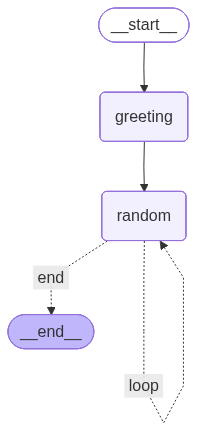

In [6]:
from  IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
app.invoke({
    "name":"tom","num":[],"counter":-1
    })

entering loop 1
entering loop 2
entering loop 3
entering loop 4
exiting loop 5


{'name': 'Hi there,tom!  ', 'num': [6, 5, 0, 7, 7], 'counter': 5}